# Exploratory Data Analysis — NaijaSenti PCM Dataset

This notebook explores the Nigerian Pidgin (PCM) split of the NaijaSenti dataset used to train a sentiment classifier for analysing public reaction to the Naira/USD exchange rate.

**Dataset:** NaijaSenti PCM — 10,559 tweets (train/dev/test splits)  
**Task:** Binary sentiment classification (positive vs negative)  
**Model:** AfriBERTa fine-tuned on PCM tweets

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import re
import os
import sys

sys.path.insert(0, os.path.abspath('..'))

from src.loader import load_all
from src.preprocess import clean_text

# plot styling
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['font.family'] = 'DejaVu Sans'
sns.set_style('whitegrid')

DATA_DIR = os.path.abspath('../data/raw')

# load data
train_df, dev_df, test_df = load_all(DATA_DIR)
full_df = pd.concat([train_df, dev_df, test_df], ignore_index=True)

print(f"Train: {len(train_df)} | Dev: {len(dev_df)} | Test: {len(test_df)} | Total: {len(full_df)}")

Train: 5049 | Dev: 1260 | Test: 3723 | Total: 10032


## 1. Class Distribution

Before building any model, we need to understand the balance between sentiment classes in our dataset. Class imbalance is one of the most common causes of poor model performance, if a model sees far more negative examples than positive ones during training, it learns to favour negative predictions even when the evidence is ambiguous.

We dropped the neutral class entirely due to severe underrepresentation (72 out of 5,122 training examples — just 1.4%). Keeping it would have introduced a class the model could never learn meaningfully.

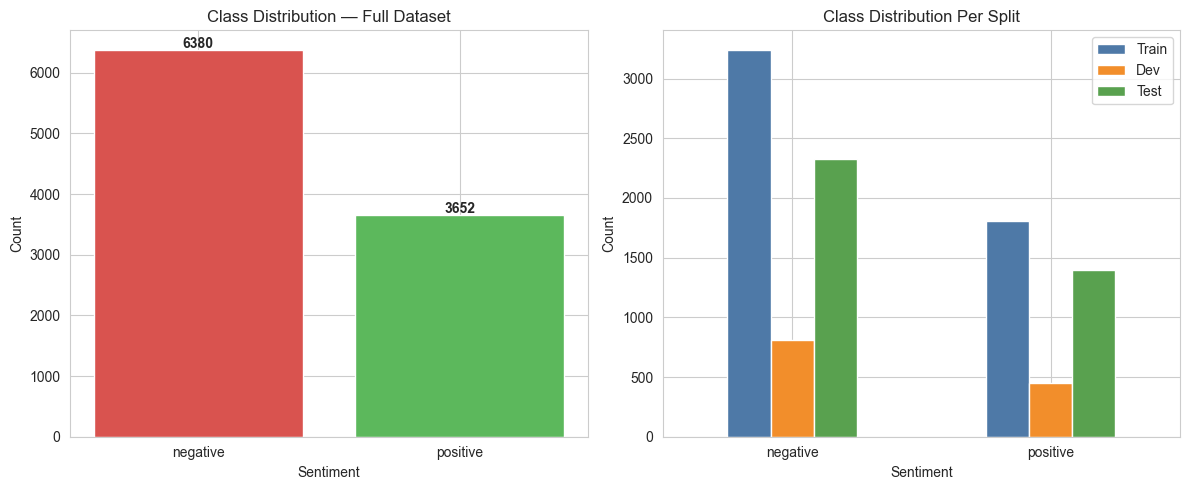


Class balance — negative: 63.6% | positive: 36.4%


In [2]:
# class distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# overall
label_counts = full_df['label'].value_counts()
axes[0].bar(label_counts.index, label_counts.values, color=['#d9534f', '#5cb85c'])
axes[0].set_title('Class Distribution — Full Dataset')
axes[0].set_xlabel('Sentiment')
axes[0].set_ylabel('Count')
for i, v in enumerate(label_counts.values):
    axes[0].text(i, v + 30, str(v), ha='center', fontweight='bold')

# per split
split_counts = pd.DataFrame({
    'Train': train_df['label'].value_counts(),
    'Dev': dev_df['label'].value_counts(),
    'Test': test_df['label'].value_counts()
})
split_counts.plot(kind='bar', ax=axes[1], color=['#4e79a7', '#f28e2b', '#59a14f'])
axes[1].set_title('Class Distribution Per Split')
axes[1].set_xlabel('Sentiment')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.savefig('../outputs/class_distribution.png', dpi=150)
plt.show()

print(f"\nClass balance — negative: {label_counts['negative']/len(full_df)*100:.1f}% | positive: {label_counts['positive']/len(full_df)*100:.1f}%")

### Observation

The dataset is moderately imbalanced — **64% negative vs 36% positive**. This imbalance is consistent across all three splits, which is good. It means the train/dev/test splits were stratified properly and the model sees the same distribution during training and evaluation.

The imbalance is significant enough to affect model performance, particularly recall on the positive class. We addressed this during training by applying class weights to the loss function, penalising the model more heavily for missing positive tweets.

## 2. Tweet Length Analysis

Understanding tweet length helps us set the right `max_length` parameter during tokenization. If most tweets are short, padding to a very large length wastes memory and slows training. We also want to check whether positive and negative tweets differ in length, which could reveal something about how people express each sentiment.

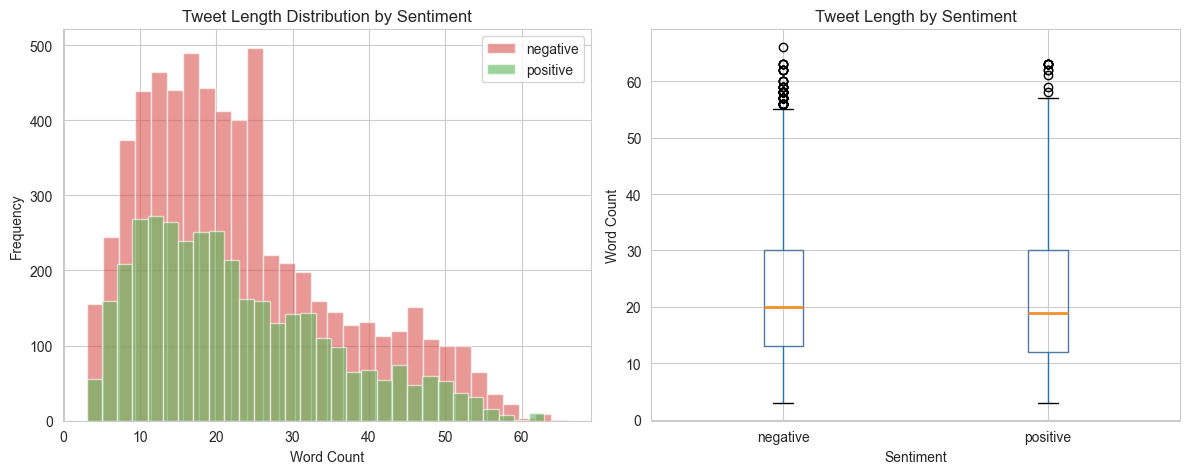

           count   mean    std  min   25%   50%   75%   max
label                                                      
negative  6380.0  23.09  12.94  3.0  13.0  20.0  30.0  66.0
positive  3652.0  22.05  12.57  3.0  12.0  19.0  30.0  63.0


In [3]:
full_df['tweet_length'] = full_df['tweet'].apply(lambda x: len(x.split()))

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# distribution by sentiment
for label, color in [('negative', '#d9534f'), ('positive', '#5cb85c')]:
    subset = full_df[full_df['label'] == label]['tweet_length']
    axes[0].hist(subset, bins=30, alpha=0.6, color=color, label=label)
axes[0].set_title('Tweet Length Distribution by Sentiment')
axes[0].set_xlabel('Word Count')
axes[0].set_ylabel('Frequency')
axes[0].legend()

# boxplot
full_df.boxplot(column='tweet_length', by='label', ax=axes[1],
                boxprops=dict(color='#4e79a7'),
                medianprops=dict(color='#f28e2b', linewidth=2))
axes[1].set_title('Tweet Length by Sentiment')
axes[1].set_xlabel('Sentiment')
axes[1].set_ylabel('Word Count')
plt.suptitle('')

plt.tight_layout()
plt.savefig('../outputs/tweet_length.png', dpi=150)
plt.show()

print(full_df.groupby('label')['tweet_length'].describe().round(2))

### Observation

Both classes follow a similar length distribution, peaking around 15 to 25 words. The median lengths are close between negative and positive tweets, suggesting sentiment is not strongly tied to how much someone writes. The majority of tweets fall well below 128 words, confirming that our tokenization `max_length` of 128 tokens was a safe and efficient choice.

## 3. Most Common Words by Sentiment

Looking at the most frequent words per class gives us a sense of what language patterns the model is picking up on. We apply our cleaning function first to remove noise before counting, otherwise URLs, mentions and punctuation would dominate the results.

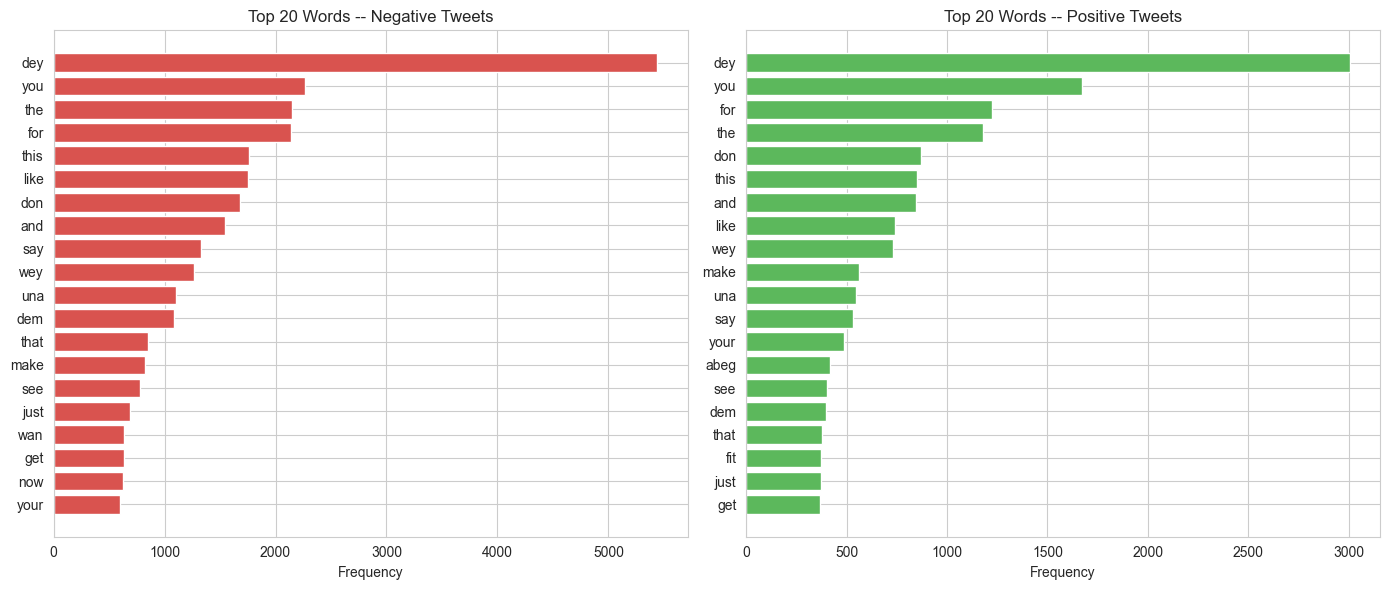

In [4]:
def get_top_words(df, label, n=20):
    tweets = df[df['label'] == label]['tweet'].apply(clean_text)
    all_words = ' '.join(tweets).split()
    # remove very short words (1-2 characters) as they add little meaning
    all_words = [w for w in all_words if len(w) > 2]
    return Counter(all_words).most_common(n)

neg_words = get_top_words(full_df, 'negative')
pos_words = get_top_words(full_df, 'positive')

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# negative
neg_labels, neg_counts = zip(*neg_words)
axes[0].barh(neg_labels[::-1], neg_counts[::-1], color='#d9534f')
axes[0].set_title('Top 20 Words -- Negative Tweets')
axes[0].set_xlabel('Frequency')

# positive
pos_labels, pos_counts = zip(*pos_words)
axes[1].barh(pos_labels[::-1], pos_counts[::-1], color='#5cb85c')
axes[1].set_title('Top 20 Words -- Positive Tweets')
axes[1].set_xlabel('Frequency')

plt.tight_layout()
plt.savefig('../outputs/top_words.png', dpi=150)
plt.show()

### Observation

The most frequent words across both classes are general pidgin function words ``"dey", "you", "don", "wey", "una"`` rather than topic-specific words. This tells us the NaijaSenti dataset covers general Nigerian Pidgin conversation, not a specific topic like finance or politics. The word lists are strikingly similar between the two classes, with no obvious sentiment-specific vocabulary standing out. This is actually an important finding, it confirms that sentiment in pidgin cannot be determined by word frequency alone. The meaning depends heavily on context and sentence structure, which is exactly why a transformer model like AfriBERTa that understands context is a better fit than simpler approaches like TF-IDF with bag-of-words.

## 4. Sample Tweets by Sentiment

Looking at actual tweet examples grounds our understanding of the data. Reading real examples helps us appreciate the diversity of pidgin expression and the genuine difficulty of the task, particularly for edge cases like sarcasm and ambiguous phrasing.

In [5]:
np.random.seed(42)

print("NEGATIVE SAMPLES")
print("=" * 60)
neg_samples = train_df[train_df['label'] == 'negative']['tweet'].sample(5)
for i, tweet in enumerate(neg_samples, 1):
    print(f"{i}. {tweet}\n")

print("POSITIVE SAMPLES")
print("=" * 60)
pos_samples = train_df[train_df['label'] == 'positive']['tweet'].sample(5)
for i, tweet in enumerate(pos_samples, 1):
    print(f"{i}. {tweet}\n")

NEGATIVE SAMPLES
1. they should stop abeg na me dey suffer am

2. belle dey pain me breast dey pain me on top this fruit wey eve chop

3. onye ela dey there na poverty go cripple u dia hehehe

4. me i don send out deliveries already i dey bed dey enjoy ac come let me employ you to be frying puff puff

5. abeg wetin concern phone and chest pain sha dont show my mother this video abeg if you can relate tag two friends to see this and

POSITIVE SAMPLES
1. this your body na killer

2. weve enough option for this trip fam see cruise na

3. shey una dey listen to crest fm sha talk say them wan share babe by am o

4. na so d protest carry dem reach d spirit of benin protest atleast does ppl wey dem manage release go tnk der god

5. if anybody dey wey i don offend in one way or the other make una please slide in my dm imma apologize either im at fault or youre at fault i go apologize and let all go its december thanks love always ️



### Observation

The samples illustrate the genuine challenges of pidgin sentiment classification. Spelling is highly inconsistent, the same word can appear in multiple forms across different tweets, and some tweets express mixed sentiments within a single sentence. These characteristics make pidgin sentiment a harder task than standard English classification, and help explain why our model achieves 74% F1 macro rather than the higher scores typically seen on cleaner English datasets.

## Summary

This exploration revealed several important characteristics of the NaijaSenti PCM dataset that directly informed our modelling decisions:

- The dataset has a 64/36 negative/positive class imbalance, consistent across all splits. We addressed this during training using class weights.
- Tweet lengths are similar across both classes, peaking around 15 to 25 words. This confirmed that 128 tokens was a safe and efficient max length for tokenization.
- The most frequent words are general pidgin function words shared across both classes, confirming that context matters more than word frequency for this task. This justified our choice of AfriBERTa over simpler bag-of-words approaches.
- Real pidgin tweets are noisy, inconsistently spelled, and sometimes genuinely ambiguous. This sets realistic expectations for model performance.

These findings feed directly into the modelling decisions documented in `analysis.ipynb`.